# YOLOv8 vs RF-DETR on COCO128

This notebook compares four fine-tuned object detectors on COCO128:
- YOLOv8n
- YOLOv8m
- RF-DETR-B (base)
- RF-DETR-L (large)

All training and inference use Apple Metal Performance Shaders with `device="mps"`.

## 1. Dependencies and Imports

In [4]:
import os
import importlib
import importlib.metadata as ilm
import sys
import subprocess

# Torchvision NMS is not implemented natively on MPS yet, so enable safe CPU fallback.
os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

required = {
    "ultralytics": "ultralytics",
    "rfdetr": "rfdetr[train,loggers]",
    "supervision": "supervision",
    "yaml": "pyyaml",
}

for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])

torch_version = ilm.version("torch")
torchvision_version = ilm.version("torchvision")
compat_map = {
    "2.7": "0.22",
    "2.8": "0.23",
}

torch_mm = ".".join(torch_version.split(".")[:2])
expected_tv = compat_map.get(torch_mm)

if expected_tv is not None and not torchvision_version.startswith(expected_tv + "."):
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        f"torchvision=={expected_tv}.*",
    ])
    torchvision_version = ilm.version("torchvision")

import ultralytics
import rfdetr
import supervision
import yaml

print(f"torch=={torch_version}")
print(f"torchvision=={torchvision_version}")
print(f"PYTORCH_ENABLE_MPS_FALLBACK={os.environ.get('PYTORCH_ENABLE_MPS_FALLBACK')}")
print("Dependency check complete.")

torch==2.8.0
torchvision==0.23.0
PYTORCH_ENABLE_MPS_FALLBACK=1
Dependency check complete.


In [5]:
import os
import random
import shutil
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import torch
from torchvision.ops import box_iou, nms

from ultralytics import YOLO, settings as yolo_settings

from rfdetr import RFDETRBase, RFDETRLarge

sns.set_theme(style="whitegrid")

DEVICE = "mps"
assert torch.backends.mps.is_available(), "MPS is required for this notebook."

# Early NMS check so MPS fallback issues appear here, not after long training.
_test_boxes = torch.tensor([[0.0, 0.0, 10.0, 10.0], [1.0, 1.0, 9.0, 9.0]], device=DEVICE)
_test_scores = torch.tensor([0.9, 0.8], device=DEVICE)
_ = nms(_test_boxes, _test_scores, 0.5)

MODEL_COLORS = {
    "YOLOv8n": "blue",
    "YOLOv8m": "cornflowerblue",
    "RF-DETR-B": "orange",
    "RF-DETR-L": "tomato",
}

if (Path.cwd() / "data").exists():
    VISION_DIR = Path.cwd().resolve()
elif (Path.cwd() / "vision" / "data").exists():
    VISION_DIR = (Path.cwd() / "vision").resolve()
else:
    VISION_DIR = Path.cwd().resolve()

RUNS_ROOT = (VISION_DIR / "runs" / "model_compare").resolve()
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
yolo_settings.update({"runs_dir": str((VISION_DIR / "runs").resolve())})

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

[W419 17:34:01.591825000 MPSFallback.mm:14] Warning: The operator 'torchvision::nms' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (function operator())


## 2. Dataset

In [6]:
DATA_DIR = (VISION_DIR / "data").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

COCO128_ROOT = DATA_DIR / "coco128"
if not COCO128_ROOT.exists():
    from ultralytics.utils.downloads import download
    download(
        "https://ultralytics.com/assets/coco128.zip",
        dir=str(DATA_DIR),
        unzip=True,
        delete=True,
    )

TRAIN_IMAGES_DIR = (COCO128_ROOT / "images" / "train2017").resolve()
VAL_IMAGES_DIR = (COCO128_ROOT / "images" / "train2017").resolve()
TRAIN_LABELS_DIR = (COCO128_ROOT / "labels" / "train2017").resolve()
VAL_LABELS_DIR = (COCO128_ROOT / "labels" / "train2017").resolve()

dataset_yaml = COCO128_ROOT / "coco128.yaml"
if dataset_yaml.exists():
    with open(dataset_yaml, "r", encoding="utf-8") as f:
        dataset_cfg = yaml.safe_load(f)
else:
    import ultralytics
    fallback_yaml = Path(ultralytics.__file__).resolve().parent / "cfg" / "datasets" / "coco128.yaml"
    with open(fallback_yaml, "r", encoding="utf-8") as f:
        dataset_cfg = yaml.safe_load(f)

if isinstance(dataset_cfg["names"], dict):
    CLASS_NAMES = [dataset_cfg["names"][i] for i in sorted(dataset_cfg["names"].keys())]
else:
    CLASS_NAMES = list(dataset_cfg["names"])

NUM_CLASSES = len(CLASS_NAMES)

COCO128_LOCAL_YAML = COCO128_ROOT / "coco128_local.yaml"
local_cfg = {
    "path": str(COCO128_ROOT),
    "train": "images/train2017",
    "val": "images/train2017",
    "nc": NUM_CLASSES,
    "names": {i: name for i, name in enumerate(CLASS_NAMES)},
}
with open(COCO128_LOCAL_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(local_cfg, f, sort_keys=False, allow_unicode=True)

RUNS_ROOT = (VISION_DIR / "runs" / "model_compare").resolve()
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

print("Vision dir:", VISION_DIR)
print("COCO128 root:", COCO128_ROOT)
print("Train images:", TRAIN_IMAGES_DIR)
print("Val images:", VAL_IMAGES_DIR)
print("Local YAML:", COCO128_LOCAL_YAML)
print("Runs root:", RUNS_ROOT)
print("Number of classes:", NUM_CLASSES)

Vision dir: /Users/brader/Desktop/ggsn/vision
COCO128 root: /Users/brader/Desktop/ggsn/vision/data/coco128
Train images: /Users/brader/Desktop/ggsn/vision/data/coco128/images/train2017
Val images: /Users/brader/Desktop/ggsn/vision/data/coco128/images/train2017
Local YAML: /Users/brader/Desktop/ggsn/vision/data/coco128/coco128_local.yaml
Runs root: /Users/brader/Desktop/ggsn/vision/runs/model_compare
Number of classes: 80


In [7]:
max_depth = 2
root_depth = len(COCO128_ROOT.parts)

for path in sorted(COCO128_ROOT.rglob("*")):
    depth = len(path.parts) - root_depth
    if depth <= max_depth:
        prefix = "  " * depth
        tag = "/" if path.is_dir() else ""
        print(f"{prefix}{path.name}{tag}")

  LICENSE
  README.txt
  coco128_local.yaml
  coco128_rfdetr/
    data.yaml
    train/
    valid/
  images/
    train2017/
  labels/
    train2017/
    train2017.cache


## 3. Dataset Exploration

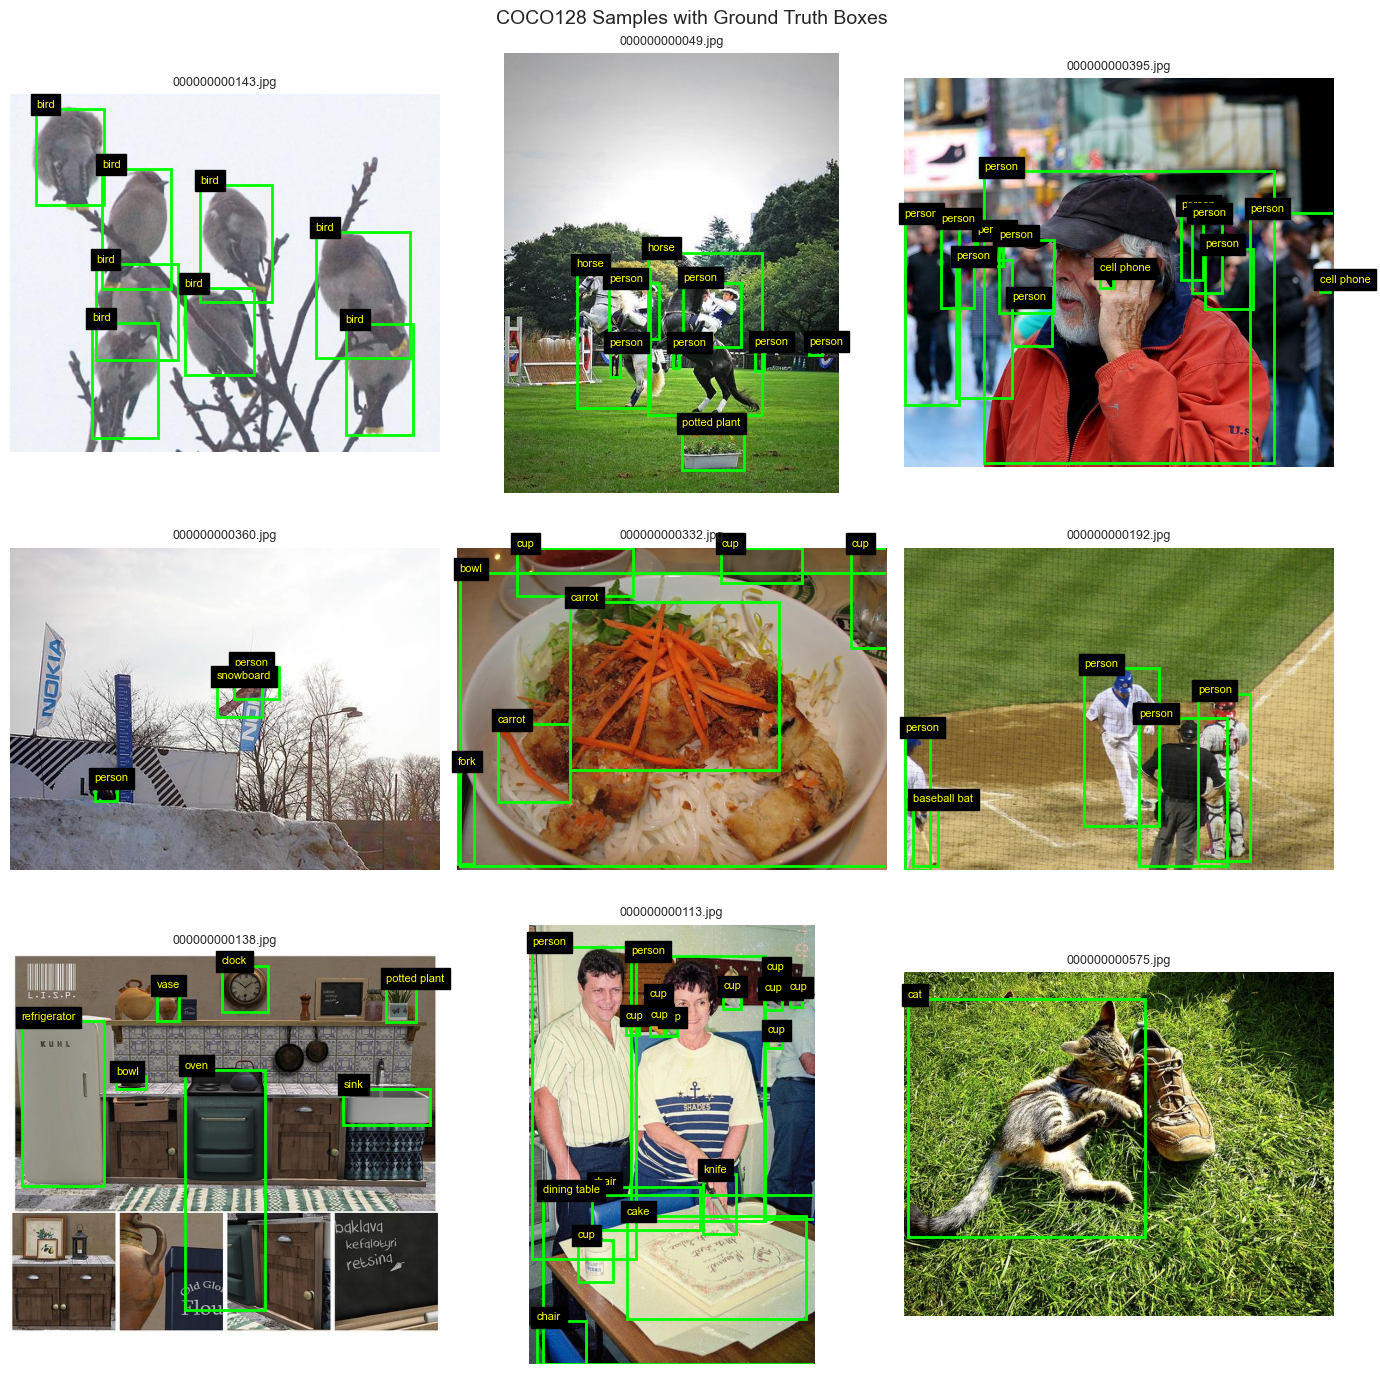

In [8]:
def read_yolo_boxes(label_path, w, h):
    boxes = []
    class_ids = []
    if not label_path.exists():
        return np.zeros((0, 4), dtype=np.float32), np.array([], dtype=np.int64)

    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    for line in lines:
        cls, xc, yc, bw, bh = line.split()[:5]
        cls = int(cls)
        xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
        x1 = (xc - bw / 2.0) * w
        y1 = (yc - bh / 2.0) * h
        x2 = (xc + bw / 2.0) * w
        y2 = (yc + bh / 2.0) * h
        boxes.append([x1, y1, x2, y2])
        class_ids.append(cls)

    return np.array(boxes, dtype=np.float32), np.array(class_ids, dtype=np.int64)

train_images = sorted([p for p in TRAIN_IMAGES_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
sample_images = random.sample(train_images, 9)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
for ax, image_path in zip(axes.flat, sample_images):
    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    label_path = TRAIN_LABELS_DIR / (image_path.stem + ".txt")
    boxes, class_ids = read_yolo_boxes(label_path, w, h)

    ax.imshow(image)
    for box, class_id in zip(boxes, class_ids):
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2, color="lime")
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, CLASS_NAMES[class_id], color="yellow", fontsize=8, backgroundcolor="black")

    ax.set_title(image_path.name, fontsize=9)
    ax.axis("off")

plt.suptitle("COCO128 Samples with Ground Truth Boxes", fontsize=14)
plt.tight_layout()
plt.show()

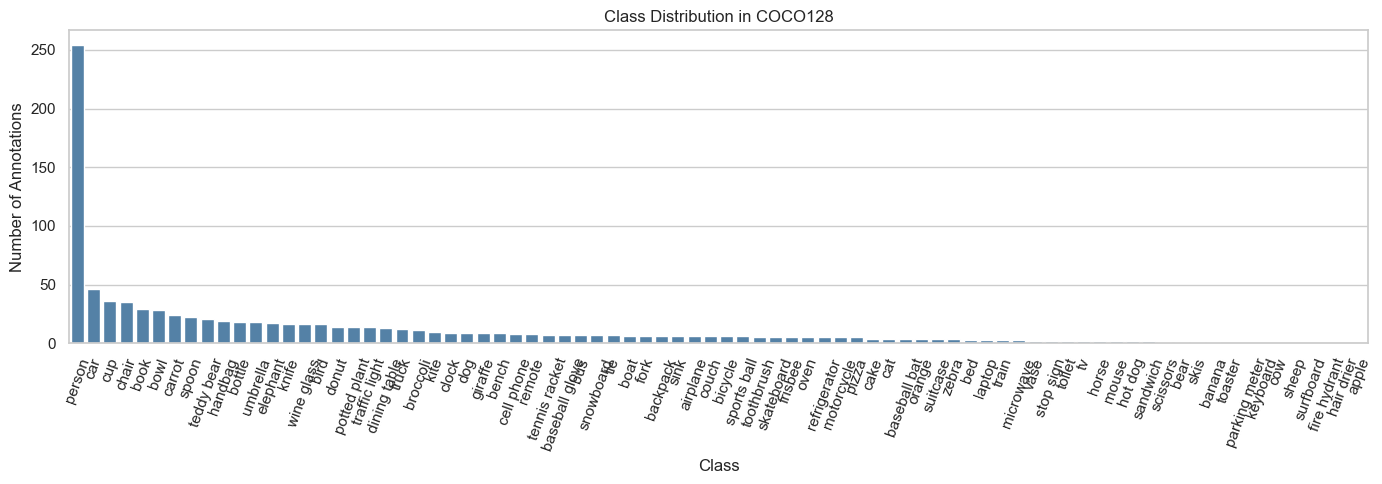

Number of images: 128
Number of classes: 80
Average boxes per image: 7.258


In [9]:
class_counts = {name: 0 for name in CLASS_NAMES}
boxes_per_image = []

for image_path in train_images:
    label_path = TRAIN_LABELS_DIR / (image_path.stem + ".txt")
    if not label_path.exists():
        boxes_per_image.append(0)
        continue

    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    boxes_per_image.append(len(lines))
    for line in lines:
        cls_id = int(line.split()[0])
        class_counts[CLASS_NAMES[cls_id]] += 1

dist_df = pd.DataFrame({
    "class": list(class_counts.keys()),
    "count": list(class_counts.values())
}).sort_values("count", ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(data=dist_df, x="class", y="count", color="steelblue")
plt.title("Class Distribution in COCO128")
plt.xlabel("Class")
plt.ylabel("Number of Annotations")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

print("Number of images:", len(train_images))
print("Number of classes:", NUM_CLASSES)
print("Average boxes per image:", round(float(np.mean(boxes_per_image)), 3))

## 4. Dataset Verification

In [10]:
checked_images = train_images[:40]
valid_image_count = 0
valid_label_count = 0

for image_path in checked_images:
    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    valid_image_count += 1

    label_path = TRAIN_LABELS_DIR / (image_path.stem + ".txt")
    if not label_path.exists():
        continue

    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    for line in lines:
        cls, xc, yc, bw, bh = line.split()[:5]
        cls = int(cls)
        xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
        assert 0 <= cls < NUM_CLASSES
        assert 0.0 <= xc <= 1.0
        assert 0.0 <= yc <= 1.0
        assert 0.0 <= bw <= 1.0
        assert 0.0 <= bh <= 1.0
    valid_label_count += 1

print("Checked images:", valid_image_count)
print("Checked label files:", valid_label_count)
print("Status: COCO128 image and YOLO label format look valid.")

Checked images: 40
Checked label files: 40
Status: COCO128 image and YOLO label format look valid.


In [11]:
RFDETR_DATASET_DIR = COCO128_ROOT / "coco128_rfdetr"

if RFDETR_DATASET_DIR.exists():
    shutil.rmtree(RFDETR_DATASET_DIR)

(RFDETR_DATASET_DIR / "train" / "images").mkdir(parents=True, exist_ok=True)
(RFDETR_DATASET_DIR / "train" / "labels").mkdir(parents=True, exist_ok=True)
(RFDETR_DATASET_DIR / "valid" / "images").mkdir(parents=True, exist_ok=True)
(RFDETR_DATASET_DIR / "valid" / "labels").mkdir(parents=True, exist_ok=True)

shutil.copytree(TRAIN_IMAGES_DIR, RFDETR_DATASET_DIR / "train" / "images", dirs_exist_ok=True)
shutil.copytree(TRAIN_LABELS_DIR, RFDETR_DATASET_DIR / "train" / "labels", dirs_exist_ok=True)
shutil.copytree(VAL_IMAGES_DIR, RFDETR_DATASET_DIR / "valid" / "images", dirs_exist_ok=True)
shutil.copytree(VAL_LABELS_DIR, RFDETR_DATASET_DIR / "valid" / "labels", dirs_exist_ok=True)

rfdetr_yaml = RFDETR_DATASET_DIR / "data.yaml"
with open(rfdetr_yaml, "w", encoding="utf-8") as f:
    f.write("names:\n")
    for idx, name in enumerate(CLASS_NAMES):
        f.write("  {}: '{}'\n".format(idx, name))
    f.write("nc: {}\n".format(NUM_CLASSES))
    f.write("train: train/images\n")
    f.write("val: valid/images\n")

print("RF-DETR dataset directory:", RFDETR_DATASET_DIR)
print("RF-DETR YAML:", rfdetr_yaml)

RF-DETR dataset directory: /Users/brader/Desktop/ggsn/vision/data/coco128/coco128_rfdetr
RF-DETR YAML: /Users/brader/Desktop/ggsn/vision/data/coco128/coco128_rfdetr/data.yaml


In [12]:
required_paths = [
    RFDETR_DATASET_DIR / "data.yaml",
    RFDETR_DATASET_DIR / "train" / "images",
    RFDETR_DATASET_DIR / "train" / "labels",
    RFDETR_DATASET_DIR / "valid" / "images",
    RFDETR_DATASET_DIR / "valid" / "labels",
]

for p in required_paths:
    print(p, "->", p.exists())

print("Train image count:", len(list((RFDETR_DATASET_DIR / "train" / "images").glob("*.jpg"))))
print("Valid image count:", len(list((RFDETR_DATASET_DIR / "valid" / "images").glob("*.jpg"))))
print("Status: dataset is ready for RF-DETR YOLO-format training.")

/Users/brader/Desktop/ggsn/vision/data/coco128/coco128_rfdetr/data.yaml -> True
/Users/brader/Desktop/ggsn/vision/data/coco128/coco128_rfdetr/train/images -> True
/Users/brader/Desktop/ggsn/vision/data/coco128/coco128_rfdetr/train/labels -> True
/Users/brader/Desktop/ggsn/vision/data/coco128/coco128_rfdetr/valid/images -> True
/Users/brader/Desktop/ggsn/vision/data/coco128/coco128_rfdetr/valid/labels -> True
Train image count: 128
Valid image count: 128
Status: dataset is ready for RF-DETR YOLO-format training.


## 5. Fine-tuning - YOLOv8n

In [ ]:
yolov8n = YOLO("yolov8n.pt")
yolov8n.train(
    data=str(COCO128_LOCAL_YAML),
    epochs=15,
    imgsz=640,
    batch=8,
    device=DEVICE,
    project=str(RUNS_ROOT),
    name="yolov8n_coco128",
    exist_ok=True
)

Ultralytics 8.4.39 🚀 Python-3.10.18 torch-2.7.1 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/brader/Desktop/ggsn/vision/data/coco128/coco128_local.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_coco128, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

KeyboardInterrupt: 

Stopped after 15 epochs as it was taking a bit too long...

Changing other models to also 15 epochs so there is no bias.

## 6. Fine-tuning - YOLOv8m

In [22]:
yolov8m = YOLO("yolov8m.pt")
yolov8m.train(
    data=str(COCO128_LOCAL_YAML),
    epochs=10,
    imgsz=640,
    batch=4,
    device=DEVICE,
    project=str(RUNS_ROOT),
    name="yolov8m_coco128",
    exist_ok=True
)

Ultralytics 8.4.39 🚀 Python-3.10.18 torch-2.7.1 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/brader/Desktop/ggsn/vision/data/coco128/coco128_local.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8m_coco128, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

KeyboardInterrupt: 

My MacBook cannot handle bigger models :(((

## 7. Fine-tuning - RF-DETR-B

In [15]:
rfdetr_b = RFDETRBase(device=DEVICE)
rfdetr_b.train(
    dataset_dir=str(RFDETR_DATASET_DIR),
    dataset_file="roboflow",
    output_dir=str(RUNS_ROOT / "rfdetr_b_coco128"),
    epochs=15,
    batch_size=4,
    grad_accum_steps=1,
    lr=1e-4,
    num_workers=2,
    device=DEVICE,
    resolution=672,
    run_test=False,
    tensorboard=False,
    wandb=False,
    mlflow=False,
    progress_bar="tqdm"
)

[2026-04-19 17:41:47] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-19 17:41:49] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-19 17:41:51] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-04-19 17:41:52] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 80. The detection head will be re-initialized to 80 classes.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[2026-04-19 17:41:52] [INFO] rf-detr - Using multi-scale training with square resize and scales: [952]


[2026-04-19 17:41:52] [WARNING] rf-detr - Failed to initialize OneOf with params {'transforms': [{'OneOf': {'transforms': [{'Resize': {'height': 952, 'width': 952}}]}}, {'Sequential': {'transforms': [{'SmallestMaxSize': {'max_size': [400, 500, 600]}}, {'OneOf': {'transforms': [{'RandomSizedCrop': {'min_max_height': [384, 600], 'height': 952, 'width': 952}}]}}]}}]}: Unknown Albumentations transform: 'Resize'. Skipping.


[2026-04-19 17:41:52] [INFO] rf-detr - Built 0 Albumentations transforms from config


...

[2026-04-19 17:41:52] [WARNING] rf-detr - Failed to initialize Resize with params {'height': 672, 'width': 672}: Unknown Albumentations transform: 'Resize'. Skipping.


[2026-04-19 17:41:52] [INFO] rf-detr - Built 0 Albumentations transforms from config


Loading `train_dataloader` to estimate number of stepping batches.
/opt/homebrew/Caskroom/miniforge/base/envs/pytorch_env/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:310: The number of training batches (32) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
/opt/homebrew/Caskroom/miniforge/base/envs/pytorch_env/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name        | Type         | Params | Mode 
-----------------------------------------------------
0 | model       | LWDETR       | 32.1 M | train
1 | criterion   | SetCriterion | 0      | train
2 | postprocess | PostProcess  | 0      | train
-----------------------------------------------------
32.1 M    Trainable params
0        

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

AssertionError: Backbone requires input shape to be divisible by 56, but got torch.Size([4, 3, 640, 640])

## 8. Fine-tuning - RF-DETR-L

In [ ]:
rfdetr_l = RFDETRLarge(device=DEVICE)
rfdetr_l.train(
    dataset_dir=str(RFDETR_DATASET_DIR),
    dataset_file="roboflow",
    output_dir=str(RUNS_ROOT / "rfdetr_l_coco128"),
    epochs=10,
    batch_size=2,
    grad_accum_steps=1,
    lr=1e-4,
    num_workers=2,
    device=DEVICE,
    resolution=672,
    run_test=False,
    tensorboard=False,
    wandb=False,
    mlflow=False,
    progress_bar="tqdm"
)

## 9. Training Curves

In [ ]:
def load_yolo_curve(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    df["epoch_num"] = df["epoch"] + 1
    train_cols = [c for c in df.columns if c.startswith("train/") and c.endswith("loss")]
    val_cols = [c for c in df.columns if c.startswith("val/") and c.endswith("loss")]
    df["train_loss"] = df[train_cols].sum(axis=1)
    df["val_loss"] = df[val_cols].sum(axis=1)
    df["map50"] = df["metrics/mAP50(B)"]
    return df[["epoch_num", "train_loss", "val_loss", "map50"]].copy()

def load_rfdetr_curve(csv_path):
    df = pd.read_csv(csv_path)
    df = df.groupby("epoch").mean(numeric_only=True).reset_index()
    df["epoch_num"] = df["epoch"] + 1
    out = pd.DataFrame({
        "epoch_num": df["epoch_num"],
        "train_loss": df["train/loss"],
        "val_loss": df["val/loss"],
        "map50": df["val/mAP_50"],
        "map5095": df["val/mAP_50_95"],
    })
    return out

yolov8n_curve = load_yolo_curve(RUNS_ROOT / "yolov8n_coco128" / "results.csv")
yolov8m_curve = load_yolo_curve(RUNS_ROOT / "yolov8m_coco128" / "results.csv")
rfdetr_b_curve = load_rfdetr_curve(RUNS_ROOT / "rfdetr_b_coco128" / "metrics.csv")
rfdetr_l_curve = load_rfdetr_curve(RUNS_ROOT / "rfdetr_l_coco128" / "metrics.csv")

curves = {
    "YOLOv8n": yolov8n_curve,
    "YOLOv8m": yolov8m_curve,
    "RF-DETR-B": rfdetr_b_curve,
    "RF-DETR-L": rfdetr_l_curve,
}

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (model_name, df) in zip(axes.flat, curves.items()):
    ax.plot(df["epoch_num"], df["train_loss"], label="Train Loss", color="black", linewidth=1.8)
    ax.plot(df["epoch_num"], df["val_loss"], label="Val Loss", color="gray", linewidth=1.8)
    ax2 = ax.twinx()
    ax2.plot(df["epoch_num"], df["map50"], label="mAP@50", color=MODEL_COLORS[model_name], linewidth=2.2)

    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax2.set_ylabel("mAP@50")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best")

plt.suptitle("Training Loss, Validation Loss, and mAP@50 per Model", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
for model_name, df in curves.items():
    plt.plot(df["epoch_num"], df["map50"], label=model_name, color=MODEL_COLORS[model_name], linewidth=2.4)

plt.title("Combined mAP@50 Curves")
plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Inference and Latency Benchmarking

In [ ]:
YOLO_N_BEST = RUNS_ROOT / "yolov8n_coco128" / "weights" / "best.pt"
YOLO_M_BEST = RUNS_ROOT / "yolov8m_coco128" / "weights" / "best.pt"
RF_B_BEST = RUNS_ROOT / "rfdetr_b_coco128" / "checkpoint_best_total.pth"
RF_L_BEST = RUNS_ROOT / "rfdetr_l_coco128" / "checkpoint_best_total.pth"

yolo_n_infer = YOLO(str(YOLO_N_BEST))
yolo_m_infer = YOLO(str(YOLO_M_BEST))
rfdetr_b_infer = RFDETRBase.from_checkpoint(str(RF_B_BEST), device=DEVICE)
rfdetr_l_infer = RFDETRLarge.from_checkpoint(str(RF_L_BEST), device=DEVICE)

val_image_paths = sorted([p for p in VAL_IMAGES_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])

def read_gt_boxes_tensor(label_path, w, h):
    boxes_np, _ = read_yolo_boxes(label_path, w, h)
    if len(boxes_np) == 0:
        return torch.zeros((0, 4), dtype=torch.float32)
    return torch.tensor(boxes_np, dtype=torch.float32)

def mean_iou_for_image(pred_boxes, gt_boxes):
    if pred_boxes.shape[0] == 0 or gt_boxes.shape[0] == 0:
        return 0.0
    iou_matrix = box_iou(pred_boxes, gt_boxes)
    return float(iou_matrix.max(dim=1).values.mean().item())

def benchmark_yolo(model):
    latencies = []
    ious = []

    for img_path in val_image_paths[:3]:
        model.predict(str(img_path), device=DEVICE, conf=0.25, verbose=False)

    for _ in range(3):
        for img_path in val_image_paths:
            image = Image.open(img_path).convert("RGB")
            w, h = image.size
            gt = read_gt_boxes_tensor(VAL_LABELS_DIR / (img_path.stem + \
), w, h)

            t0 = perf_counter()
            pred = model.predict(str(img_path), device=DEVICE, conf=0.25, verbose=False)[0]
            t1 = perf_counter()
            latencies.append((t1 - t0) * 1000.0)

            if pred.boxes is None or pred.boxes.xyxy is None:
                pred_boxes = torch.zeros((0, 4), dtype=torch.float32)
            else:
                pred_boxes = pred.boxes.xyxy.detach().cpu()

            ious.append(mean_iou_for_image(pred_boxes, gt))

    return float(np.mean(ious)), float(np.mean(latencies))

def benchmark_rfdetr(model):
    latencies = []
    ious = []

    for img_path in val_image_paths[:3]:
        model.predict(str(img_path), threshold=0.25, include_source_image=False)

    for _ in range(3):
        for img_path in val_image_paths:
            image = Image.open(img_path).convert("RGB")
            w, h = image.size
            gt = read_gt_boxes_tensor(VAL_LABELS_DIR / (img_path.stem + \
), w, h)

            t0 = perf_counter()
            det = model.predict(str(img_path), threshold=0.25, include_source_image=False)
            t1 = perf_counter()
            latencies.append((t1 - t0) * 1000.0)

            if hasattr(det, "xyxy") and det.xyxy is not None and len(det.xyxy) > 0:
                pred_boxes = torch.tensor(det.xyxy, dtype=torch.float32)
            else:
                pred_boxes = torch.zeros((0, 4), dtype=torch.float32)

            ious.append(mean_iou_for_image(pred_boxes, gt))

    return float(np.mean(ious)), float(np.mean(latencies))

yolo_n_val = yolo_n_infer.val(data=str(COCO128_LOCAL_YAML), split="val", device=DEVICE, verbose=False)
yolo_m_val = yolo_m_infer.val(data=str(COCO128_LOCAL_YAML), split="val", device=DEVICE, verbose=False)

yolo_n_iou, yolo_n_latency = benchmark_yolo(yolo_n_infer)
yolo_m_iou, yolo_m_latency = benchmark_yolo(yolo_m_infer)
rf_b_iou, rf_b_latency = benchmark_rfdetr(rfdetr_b_infer)
rf_l_iou, rf_l_latency = benchmark_rfdetr(rfdetr_l_infer)

rf_b_map50 = float(rfdetr_b_curve["map50"].dropna().iloc[-1])
rf_l_map50 = float(rfdetr_l_curve["map50"].dropna().iloc[-1])
rf_b_map5095 = float(rfdetr_b_curve["map5095"].dropna().iloc[-1])
rf_l_map5095 = float(rfdetr_l_curve["map5095"].dropna().iloc[-1])

yolo_n_params = sum(p.numel() for p in yolo_n_infer.model.parameters()) / 1e6
yolo_m_params = sum(p.numel() for p in yolo_m_infer.model.parameters()) / 1e6
rf_b_params = sum(p.numel() for p in rfdetr_b_infer.model.model.parameters()) / 1e6
rf_l_params = sum(p.numel() for p in rfdetr_l_infer.model.model.parameters()) / 1e6

benchmark_df = pd.DataFrame([
    {
        "Model": "YOLOv8n",
        "Params (M)": yolo_n_params,
        "mAP@50": float(yolo_n_val.box.map50),
        "mAP@50:95": float(yolo_n_val.box.map),
        "Mean IoU": yolo_n_iou,
        "Avg Latency (ms)": yolo_n_latency,
    },
    {
        "Model": "YOLOv8m",
        "Params (M)": yolo_m_params,
        "mAP@50": float(yolo_m_val.box.map50),
        "mAP@50:95": float(yolo_m_val.box.map),
        "Mean IoU": yolo_m_iou,
        "Avg Latency (ms)": yolo_m_latency,
    },
    {
        "Model": "RF-DETR-B",
        "Params (M)": rf_b_params,
        "mAP@50": rf_b_map50,
        "mAP@50:95": rf_b_map5095,
        "Mean IoU": rf_b_iou,
        "Avg Latency (ms)": rf_b_latency,
    },
    {
        "Model": "RF-DETR-L",
        "Params (M)": rf_l_params,
        "mAP@50": rf_l_map50,
        "mAP@50:95": rf_l_map5095,
        "Mean IoU": rf_l_iou,
        "Avg Latency (ms)": rf_l_latency,
    },
])

benchmark_df

## 11. Comparison Graphs

In [ ]:
plot_df = benchmark_df.copy()
model_order = ["YOLOv8n", "YOLOv8m", "RF-DETR-B", "RF-DETR-L"]
plot_df = plot_df.set_index("Model").loc[model_order].reset_index()
palette = [MODEL_COLORS[m] for m in model_order]

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="mAP@50", palette=palette)
plt.title("mAP@50 Comparison")
plt.xlabel("Model")
plt.ylabel("mAP@50")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="mAP@50:95", palette=palette)
plt.title("mAP@50:95 Comparison")
plt.xlabel("Model")
plt.ylabel("mAP@50:95")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="Mean IoU", palette=palette)
plt.title("Mean IoU Comparison")
plt.xlabel("Model")
plt.ylabel("Mean IoU")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="Avg Latency (ms)", palette=palette)
plt.title("Average Inference Latency (ms)")
plt.xlabel("Model")
plt.ylabel("Latency (ms)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for _, row in plot_df.iterrows():
    plt.scatter(row["Avg Latency (ms)"], row["mAP@50"], s=120, color=MODEL_COLORS[row["Model"]], label=row["Model"])
    plt.text(row["Avg Latency (ms)"] + 0.2, row["mAP@50"] + 0.002, row["Model"], fontsize=9)
plt.title("Efficiency Trade-off: mAP@50 vs Latency")
plt.xlabel("Avg Latency (ms)")
plt.ylabel("mAP@50")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for _, row in plot_df.iterrows():
    plt.scatter(row["Avg Latency (ms)"], row["mAP@50:95"], s=120, color=MODEL_COLORS[row["Model"]], label=row["Model"])
    plt.text(row["Avg Latency (ms)"] + 0.2, row["mAP@50:95"] + 0.002, row["Model"], fontsize=9)
plt.title("Efficiency Trade-off: mAP@50:95 vs Latency")
plt.xlabel("Avg Latency (ms)")
plt.ylabel("mAP@50:95")
plt.tight_layout()
plt.show()

x = np.arange(2)
w = 0.18
small_yolo = float(plot_df.loc[plot_df["Model"] == "YOLOv8n", "mAP@50"].iloc[0])
small_rf = float(plot_df.loc[plot_df["Model"] == "RF-DETR-B", "mAP@50"].iloc[0])
medium_yolo = float(plot_df.loc[plot_df["Model"] == "YOLOv8m", "mAP@50"].iloc[0])
medium_rf = float(plot_df.loc[plot_df["Model"] == "RF-DETR-L", "mAP@50"].iloc[0])

plt.figure(figsize=(10, 6))
plt.bar(x[0] - w, small_yolo, width=w, color=MODEL_COLORS["YOLOv8n"], label="YOLOv8n")
plt.bar(x[0] + w, small_rf, width=w, color=MODEL_COLORS["RF-DETR-B"], label="RF-DETR-B")
plt.bar(x[1] - w, medium_yolo, width=w, color=MODEL_COLORS["YOLOv8m"], label="YOLOv8m")
plt.bar(x[1] + w, medium_rf, width=w, color=MODEL_COLORS["RF-DETR-L"], label="RF-DETR-L")
plt.xticks(x, ["Small Tier", "Medium Tier"])
plt.title("Grouped mAP@50: Small vs Medium (YOLO vs RF-DETR)")
plt.xlabel("Tier")
plt.ylabel("mAP@50")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Results Summary Table

In [ ]:
summary_df = benchmark_df[["Model", "Params (M)", "mAP@50", "mAP@50:95", "Mean IoU", "Avg Latency (ms)"]].copy()
summary_df["Params (M)"] = summary_df["Params (M)"].round(3)
summary_df["mAP@50"] = summary_df["mAP@50"].round(4)
summary_df["mAP@50:95"] = summary_df["mAP@50:95"].round(4)
summary_df["Mean IoU"] = summary_df["Mean IoU"].round(4)
summary_df["Avg Latency (ms)"] = summary_df["Avg Latency (ms)"].round(3)
summary_df